#### Varadharajan K, CB.SC.P2AIE25030 - 24AI636 - Deep Learning

#### Project: Voice-Based Stress Load Detection - Review 1: CNN and MLP

# Voice-Based Stress Detection using Deep Learning

## Project Overview

This project aims to detect **stress levels from speech signals** using deep learning techniques. Human speech contains acoustic and temporal patterns that reflect emotional and psychological states. By analyzing these patterns, machine learning models can learn to distinguish between **low-stress and high-stress speech signals**.

The project is implemented as part of a **Deep Learning coursework scaffolded project**, where different model architectures are explored and compared systematically.

---

## Problem Statement

Given an input speech recording, the goal is to classify the speech signal into:

- **Low Stress**
- **High Stress**

The classification is performed using extracted acoustic features and deep learning models capable of learning spatial and temporal patterns.

---

## Dataset

The project uses the **RAVDESS Emotional Speech Audio Dataset**, which contains speech recordings of actors expressing different emotions.

Dataset Source:  
https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio

Emotion-to-stress mapping used in this project:

| Emotion | Stress Label |
|-------|-------------|
| Neutral | Low Stress |
| Calm | Low Stress |
| Sad | Low Stress |
| Angry | High Stress |
| Fearful | High Stress |
| Disgust | High Stress |
| Surprised | High Stress |

---

## Project Pipeline

The overall workflow of the project is as follows:

1. Audio preprocessing
2. Feature extraction (MFCC / Mel Spectrogram)
3. Data visualization and exploratory analysis
4. Model training and validation
5. Performance evaluation
6. Model comparison and analysis

---

## Deep Learning Models Explored

### Review 1 – Baseline Models
- Multi-Layer Perceptron (MLP)
- Convolutional Neural Network (CNN)

### Review 2 – Advanced Models
Sequence Models:
- Recurrent Neural Network (RNN)
- Long Short-Term Memory (LSTM)
- Gated Recurrent Unit (GRU)
- Attention-based LSTM

Transfer Learning Models:
- ResNet18
- MobileNetV2

---

## Evaluation Metrics

The models are evaluated using multiple metrics to ensure robust performance comparison:

- Accuracy
- Precision / Recall
- F1 Score
- Confusion Matrix
- ROC Curve
- ROC-AUC Score

---

## Expected Learning Outcomes

This project demonstrates:

- Feature representation of audio signals
- Temporal modeling using sequence networks
- Transfer learning with pretrained CNN architectures
- Hyperparameter experimentation
- Comparative analysis of deep learning models

---

## Reproducibility

To ensure reproducible results, the experiments use fixed random seeds for:

- Python random module
- NumPy
- PyTorch

---

## Author
Varadharajan K <br> 
Deep Learning Project: Voice-Based Stress Detection

In [ ]:
#installing necessary libraries
!pip install torch torchvision torchaudio librosa numpy pandas scikit-learn matplotlib seaborn tqdm kagglehub


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#importing necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import librosa
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from collections import Counter
import os
import kagglehub

c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [ ]:
#setting random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [ ]:
#downloading the RAVDESS dataset using kagglehub
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

if "ravdess-emotional-speech-audio" in os.listdir(path):
    path = os.path.join(path, "ravdess-emotional-speech-audio")

print("Dataset Path:", path)

Dataset Path: C:\Users\VARADHARAJAN K\.cache\kagglehub\datasets\uwrfkaggler\ravdess-emotional-speech-audio\versions\1


In [ ]:
#class for audio feature extraction
class AudioFeatureExtractor:

    def __init__(self, sample_rate=22050, n_mfcc=40):
        self.sample_rate = sample_rate
        self.n_mfcc = n_mfcc

    def load_audio(self, file_path):
        signal, _ = librosa.load(file_path, sr=self.sample_rate)
        return signal

    def extract_mfcc(self, signal):
        return librosa.feature.mfcc(
            y=signal,
            sr=self.sample_rate,
            n_mfcc=self.n_mfcc
        )

    def extract_mel(self, signal):
        mel = librosa.feature.melspectrogram(
            y=signal,
            sr=self.sample_rate
        )
        return librosa.power_to_db(mel, ref=np.max)
    
    # Add noise
    def add_noise(self, signal, noise_factor=0.005):
        noise = np.random.randn(len(signal))
        return signal + noise_factor * noise

    #  Time shift
    def time_shift(self, signal, shift_max=0.2):
        shift = int(np.random.uniform(-shift_max, shift_max) * len(signal))
        return np.roll(signal, shift)

    #  Pitch shift
    def pitch_shift(self, signal):
        return librosa.effects.pitch_shift(
            signal,
            sr=self.sample_rate,
            n_steps=np.random.randint(-2, 3)
        )

    # Feature normalization (Z-score)
    def normalize(self, feature):
        return (feature - np.mean(feature)) / (np.std(feature) + 1e-6)

    def pad_or_truncate(self, feature, max_len=173):
        if feature.shape[1] < max_len:
            pad_width = max_len - feature.shape[1]
            feature = np.pad(feature, ((0,0),(0,pad_width)))
        else:
            feature = feature[:, :max_len]
        return feature

In [ ]:
#class for RAVDESS stress dataset
class RAVDESSStressDataset(Dataset):

    def __init__(self, root_dir, feature_type="mfcc", normalize=True, augment=False):
        self.root_dir = root_dir
        self.feature_type = feature_type
        self.extractor = AudioFeatureExtractor()
        self.normalize = normalize
        self.augment = augment
        self.file_paths = []
        self.labels = []
        self._load_dataset()

    def _emotion_to_stress(self, emotion_id):
        emotion_id = int(emotion_id)
        low = [1,2,4]      # Neutral, Calm, Sad
        high = [5,6,7,8]   # Angry, Fear, Disgust, Surprise

        if emotion_id in low:
            return 0
        elif emotion_id in high:
            return 1
        else:
            return None

    def _load_dataset(self):
        for actor in os.listdir(self.root_dir):
            actor_path = os.path.join(self.root_dir, actor)
            for file in os.listdir(actor_path):
                if file.endswith(".wav"):
                    emotion_id = file.split("-")[2]
                    label = self._emotion_to_stress(emotion_id)
                    if label is not None:
                        self.file_paths.append(os.path.join(actor_path, file))
                        self.labels.append(label)

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        label = self.labels[idx]

        signal = self.extractor.load_audio(file_path)

        # Apply augmentation only during training
        if self.augment:
            if np.random.rand() < 0.5:
                signal = self.extractor.add_noise(signal)

            if np.random.rand() < 0.5:
                signal = self.extractor.time_shift(signal)

            if np.random.rand() < 0.3:
                signal = self.extractor.pitch_shift(signal)

        if self.feature_type == "mfcc":
            feature = self.extractor.extract_mfcc(signal)
        else:
            feature = self.extractor.extract_mel(signal)

        feature = self.extractor.pad_or_truncate(feature)
        feature = self.extractor.normalize(feature)  # normalization added

        feature = torch.tensor(feature, dtype=torch.float32)

        if self.feature_type == "mel":
            feature = feature.unsqueeze(0)

        return feature, torch.tensor(label, dtype=torch.long)

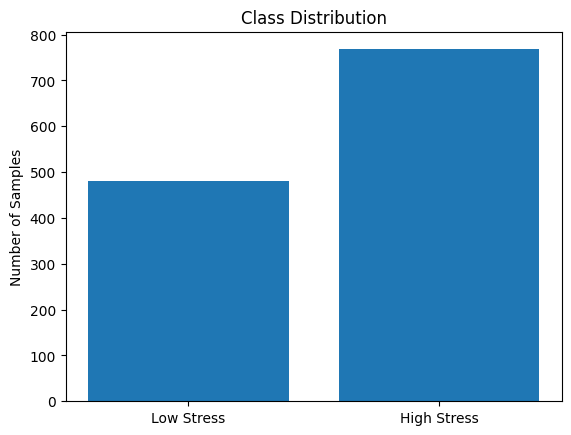

In [ ]:
#visualizing class distribution
dataset_vis = RAVDESSStressDataset(path)

counts = Counter(dataset_vis.labels)
plt.bar(["Low Stress", "High Stress"],
        [counts[0], counts[1]])
plt.title("Class Distribution")
plt.ylabel("Number of Samples")
plt.show()

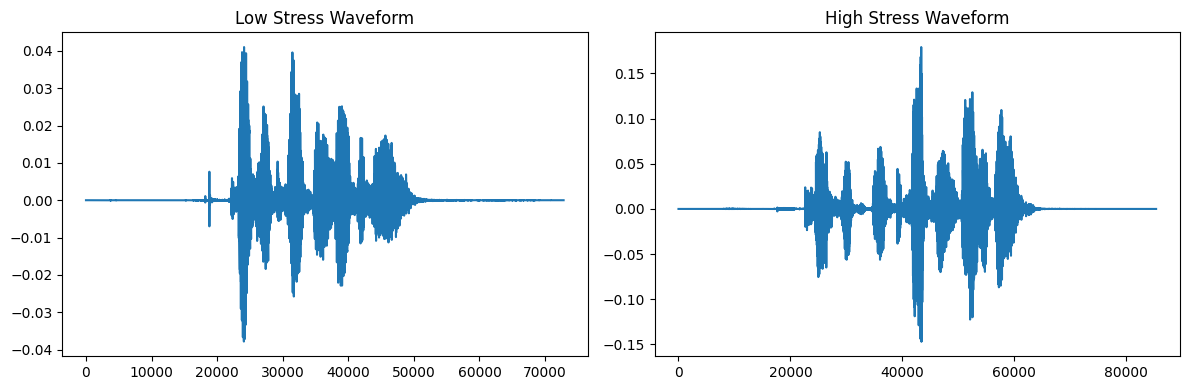

In [ ]:
#visualizing waveforms of low and high stress samples
extractor = AudioFeatureExtractor()
low_file, high_file = None, None

for f, label in zip(dataset_vis.file_paths, dataset_vis.labels):
    if label == 0 and low_file is None:
        low_file = f
    if label == 1 and high_file is None:
        high_file = f
    if low_file and high_file:
        break

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(extractor.load_audio(low_file))
plt.title("Low Stress Waveform")

plt.subplot(1,2,2)
plt.plot(extractor.load_audio(high_file))
plt.title("High Stress Waveform")
plt.tight_layout()
plt.show()

Feature shape: torch.Size([1, 128, 173])


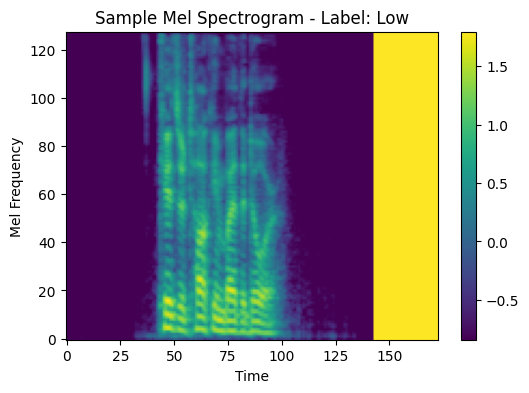

In [ ]:
#visualizing a sample mel spectrogram
dataset_mel = RAVDESSStressDataset(
    path,
    feature_type="mel",
    normalize=True,
    augment=False
)

mel_feature, mel_label = dataset_mel[0]

print("Feature shape:", mel_feature.shape)

plt.figure(figsize=(6,4))
plt.imshow(mel_feature.squeeze().numpy(), aspect="auto", origin="lower")
plt.title(f"Sample Mel Spectrogram - Label: {'Low' if mel_label.item()==0 else 'High'}")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")
plt.colorbar()
plt.show()


In [ ]:
#defining the MLP classifier
class MLPClassifier(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

In [ ]:
#defining the CNN classifier
class CNNClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        # Feature extractor
        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            # Block 3 
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
        )

        #  Adaptive pooling ensures fixed output size
        self.global_pool = nn.AdaptiveAvgPool2d((4, 4))

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

In [ ]:
#early stopping implementation
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.best_loss = None
        self.counter = 0
        self.best_model_state = None

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            self.best_model_state = model.state_dict()
        else:
            self.counter += 1
        return self.counter >= self.patience

In [ ]:
#main trainer class that handles data preparation, training, and evaluation
class Review1Trainer:

    def __init__(self, data_path, batch_size=32, epochs=20, lr=0.001):
        self.data_path = data_path
        self.batch_size = batch_size
        self.epochs = epochs
        self.lr = lr
        self.device = device

    def prepare_data(self, feature_type):
        dataset = RAVDESSStressDataset(self.data_path, feature_type, normalize=True, augment=False)

        train_size = int(0.7 * len(dataset))
        val_size = int(0.15 * len(dataset))
        test_size = len(dataset) - train_size - val_size

        train_set, val_set, test_set = random_split(
            dataset,
            [train_size, val_size, test_size],
            generator=torch.Generator().manual_seed(42)
        )
        
        train_set.dataset.augment = True

        return (
            DataLoader(train_set, batch_size=self.batch_size, shuffle=True),
            DataLoader(val_set, batch_size=self.batch_size),
            DataLoader(test_set, batch_size=self.batch_size),
            dataset.labels
        )

    def train(self, model, train_loader, val_loader, labels):

        model.to(self.device)

        class_counts = Counter(labels)
        total = sum(class_counts.values())
        weights = torch.tensor(
            [total/class_counts[0], total/class_counts[1]],
            dtype=torch.float32
        ).to(self.device)

        criterion = nn.CrossEntropyLoss(weight=weights)
        optimizer = optim.Adam(model.parameters(), lr=self.lr)
        early_stop = EarlyStopping()

        train_losses, val_losses = [], []

        for epoch in range(self.epochs):

            model.train()
            train_loss = 0
            for x, y in train_loader:
                x, y = x.to(self.device), y.to(self.device)
                optimizer.zero_grad()
                loss = criterion(model(x), y)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

            train_loss /= len(train_loader)

            model.eval()
            val_loss = 0
            with torch.no_grad():
                for x, y in val_loader:
                    x, y = x.to(self.device), y.to(self.device)
                    val_loss += criterion(model(x), y).item()

            val_loss /= len(val_loader)

            train_losses.append(train_loss)
            val_losses.append(val_loss)

            print(f"Epoch {epoch+1} | Train={train_loss:.4f} | Val={val_loss:.4f}")

            if early_stop(val_loss, model):
                print("Early stopping triggered")
                break

        model.load_state_dict(early_stop.best_model_state)

        # Loss Curve
        plt.plot(train_losses, label="Train Loss")
        plt.plot(val_losses, label="Validation Loss")
        plt.legend()
        plt.title("Loss Curve")
        plt.show()

        return model

    def evaluate(self, model, test_loader):

        model.eval()
        all_preds, all_probs, all_labels = [], [], []

        with torch.no_grad():
            for x, y in test_loader:
                x = x.to(self.device)
                outputs = model(x)
                probs = torch.softmax(outputs, dim=1)[:,1]
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
                all_labels.extend(y.numpy())

        print(classification_report(all_labels, all_preds))

        cm = confusion_matrix(all_labels, all_preds)
        sns.heatmap(cm, annot=True, fmt="d",
                    xticklabels=["Low","High"],
                    yticklabels=["Low","High"])
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

        fpr, tpr, _ = roc_curve(all_labels, all_probs)
        auc = roc_auc_score(all_labels, all_probs)
        plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
        plt.plot([0,1],[0,1],'--')
        plt.legend()
        plt.title("ROC Curve")
        plt.show()

    def run(self):

        results = {}
        lk = [0.0001, 0.0005, 0.001, 0.005]
        for lr in lk:
            print(f"\nTraining with LR={lr}")
            self.lr = lr

            # MLP
            print("MLP:")
            train_loader, val_loader, test_loader, labels = self.prepare_data("mfcc")
            sample, _ = next(iter(train_loader))
            input_size = sample.view(sample.size(0), -1).shape[1]
            mlp = MLPClassifier(input_size)
            mlp = self.train(mlp, train_loader, val_loader, labels)
            print("MLP Results:")
            self.evaluate(mlp, test_loader)

            # CNN
            print("CNN:")
            train_loader, val_loader, test_loader, labels = self.prepare_data("mel")
            cnn = CNNClassifier()
            cnn = self.train(cnn, train_loader, val_loader, labels)
            print("CNN Results:")
            self.evaluate(cnn, test_loader)

            results[lr] = {"mlp": mlp,
                           "cnn": cnn}

        return results


Training with LR=0.0001
MLP:
Epoch 1 | Train=0.6951 | Val=0.6771
Epoch 2 | Train=0.6837 | Val=0.6636
Epoch 3 | Train=0.6669 | Val=0.6493
Epoch 4 | Train=0.6444 | Val=0.6326
Epoch 5 | Train=0.6206 | Val=0.6006
Epoch 6 | Train=0.6038 | Val=0.5780
Epoch 7 | Train=0.5976 | Val=0.6041
Epoch 8 | Train=0.5893 | Val=0.5743
Epoch 9 | Train=0.5881 | Val=0.5654
Epoch 10 | Train=0.5764 | Val=0.5638
Epoch 11 | Train=0.5646 | Val=0.5968
Epoch 12 | Train=0.5820 | Val=0.5950
Epoch 13 | Train=0.5594 | Val=0.5757
Epoch 14 | Train=0.5633 | Val=0.6025
Epoch 15 | Train=0.5526 | Val=0.5509
Epoch 16 | Train=0.5450 | Val=0.5710
Epoch 17 | Train=0.5589 | Val=0.5586
Epoch 18 | Train=0.5543 | Val=0.5229
Epoch 19 | Train=0.5458 | Val=0.6174
Epoch 20 | Train=0.5876 | Val=0.5540


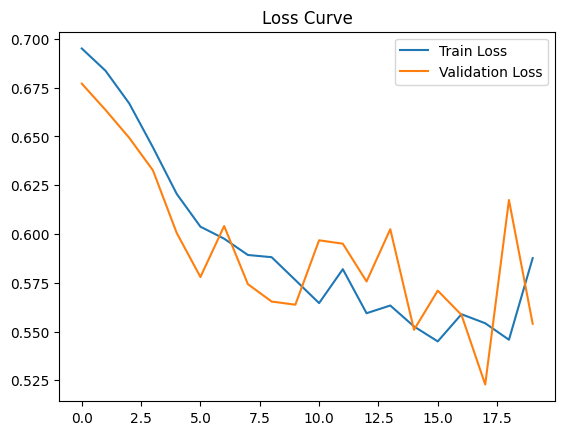

MLP Results:
              precision    recall  f1-score   support

           0       0.78      0.80      0.79        83
           1       0.83      0.82      0.83       105

    accuracy                           0.81       188
   macro avg       0.81      0.81      0.81       188
weighted avg       0.81      0.81      0.81       188



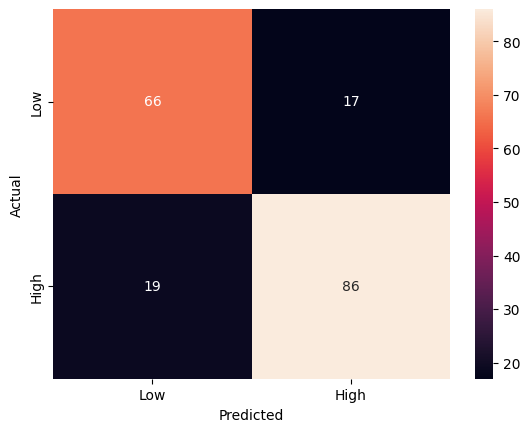

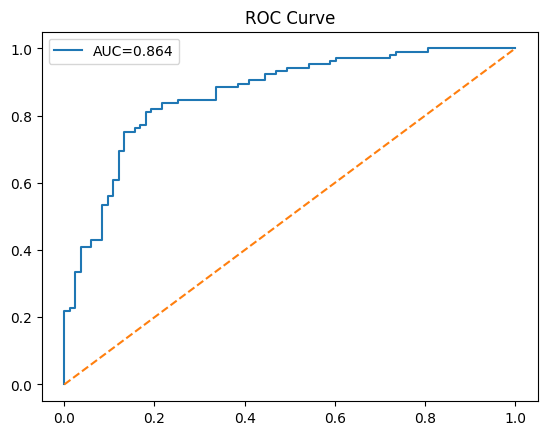

CNN:
Epoch 1 | Train=0.6635 | Val=0.6563
Epoch 2 | Train=0.6030 | Val=0.5901
Epoch 3 | Train=0.5883 | Val=0.5541
Epoch 4 | Train=0.5533 | Val=0.5263
Epoch 5 | Train=0.5161 | Val=0.5040
Epoch 6 | Train=0.5042 | Val=0.4878
Epoch 7 | Train=0.5033 | Val=0.5089
Epoch 8 | Train=0.4563 | Val=0.4919
Epoch 9 | Train=0.4457 | Val=0.4939
Epoch 10 | Train=0.4650 | Val=0.4458
Epoch 11 | Train=0.4365 | Val=0.4270
Epoch 12 | Train=0.4370 | Val=0.4267
Epoch 13 | Train=0.3934 | Val=0.4571
Epoch 14 | Train=0.3879 | Val=0.4257
Epoch 15 | Train=0.3878 | Val=0.3993
Epoch 16 | Train=0.3706 | Val=0.4232
Epoch 17 | Train=0.3552 | Val=0.4229
Epoch 18 | Train=0.3515 | Val=0.3816
Epoch 19 | Train=0.3540 | Val=0.4371
Epoch 20 | Train=0.3533 | Val=0.4022


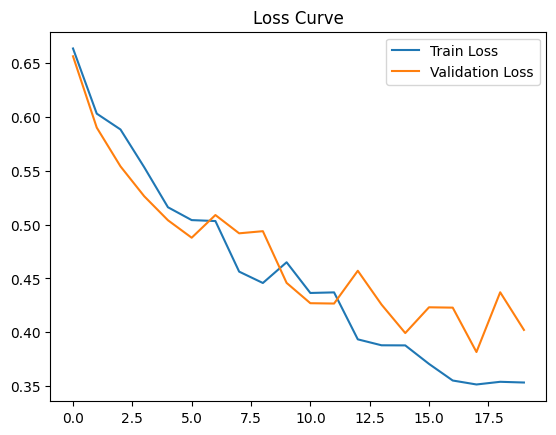

CNN Results:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82        83
           1       0.87      0.84      0.85       105

    accuracy                           0.84       188
   macro avg       0.84      0.84      0.84       188
weighted avg       0.84      0.84      0.84       188



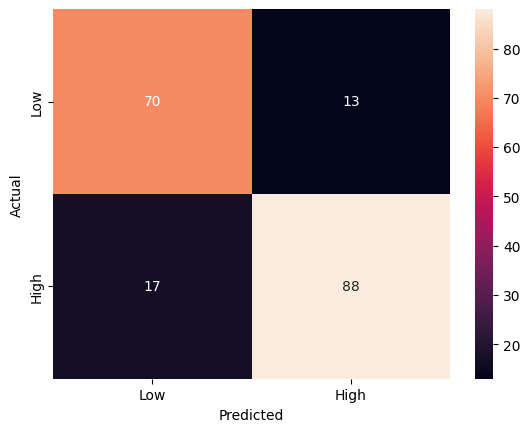

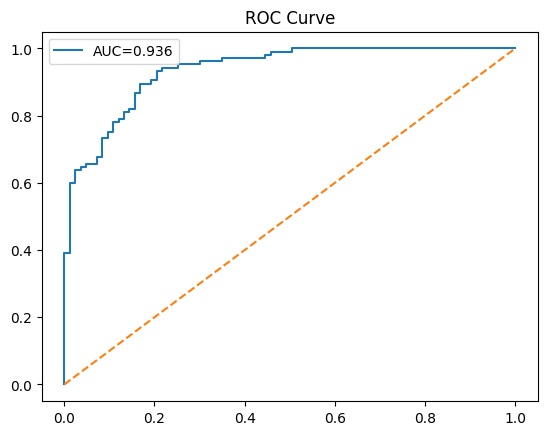


Training with LR=0.0005
MLP:
Epoch 1 | Train=0.7463 | Val=0.6634
Epoch 2 | Train=0.6815 | Val=0.6397
Epoch 3 | Train=0.6509 | Val=0.6166
Epoch 4 | Train=0.6443 | Val=0.6182
Epoch 5 | Train=0.6198 | Val=0.6122
Epoch 6 | Train=0.5899 | Val=0.6198
Epoch 7 | Train=0.5796 | Val=0.6090
Epoch 8 | Train=0.5996 | Val=0.5861
Epoch 9 | Train=0.5939 | Val=0.5790
Epoch 10 | Train=0.5774 | Val=0.5838
Epoch 11 | Train=0.5820 | Val=0.5581
Epoch 12 | Train=0.5715 | Val=0.5738
Epoch 13 | Train=0.5740 | Val=0.5601
Epoch 14 | Train=0.5514 | Val=0.5434
Epoch 15 | Train=0.5616 | Val=0.5723
Epoch 16 | Train=0.5650 | Val=0.5690
Epoch 17 | Train=0.5382 | Val=0.5729
Epoch 18 | Train=0.5416 | Val=0.5896
Epoch 19 | Train=0.5351 | Val=0.5604
Early stopping triggered


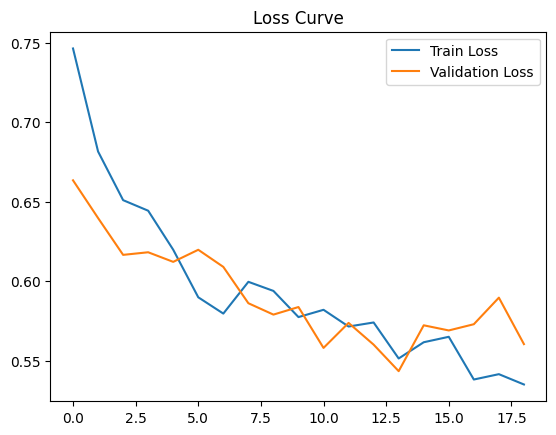

MLP Results:
              precision    recall  f1-score   support

           0       0.63      0.89      0.74        83
           1       0.87      0.58      0.70       105

    accuracy                           0.72       188
   macro avg       0.75      0.74      0.72       188
weighted avg       0.76      0.72      0.71       188



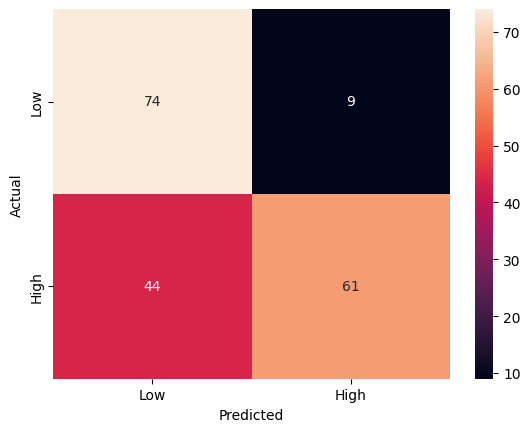

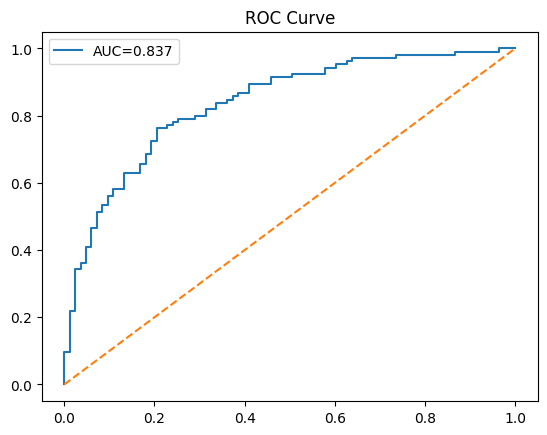

CNN:
Epoch 1 | Train=0.6775 | Val=0.6603
Epoch 2 | Train=0.6071 | Val=0.5177
Epoch 3 | Train=0.5621 | Val=0.4871
Epoch 4 | Train=0.5440 | Val=0.5446
Epoch 5 | Train=0.5610 | Val=0.5149
Epoch 6 | Train=0.4867 | Val=0.4984
Epoch 7 | Train=0.4645 | Val=0.4659
Epoch 8 | Train=0.4623 | Val=0.4330
Epoch 9 | Train=0.4136 | Val=0.4198
Epoch 10 | Train=0.4355 | Val=0.3869
Epoch 11 | Train=0.4226 | Val=0.4174
Epoch 12 | Train=0.4065 | Val=0.4018
Epoch 13 | Train=0.3947 | Val=0.4539
Epoch 14 | Train=0.3862 | Val=0.4136
Epoch 15 | Train=0.3823 | Val=0.4602
Early stopping triggered


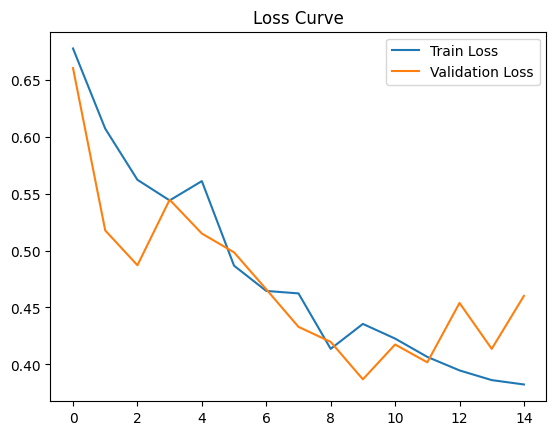

CNN Results:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86        83
           1       0.88      0.90      0.89       105

    accuracy                           0.88       188
   macro avg       0.88      0.87      0.88       188
weighted avg       0.88      0.88      0.88       188



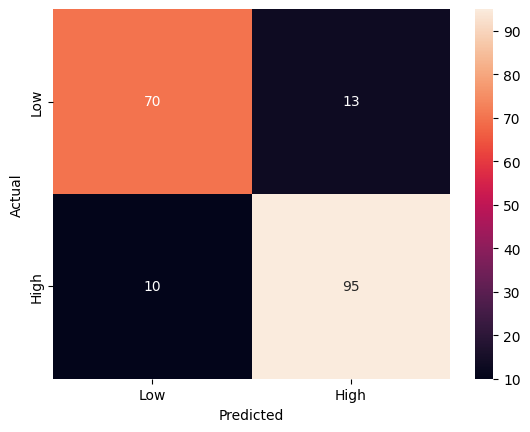

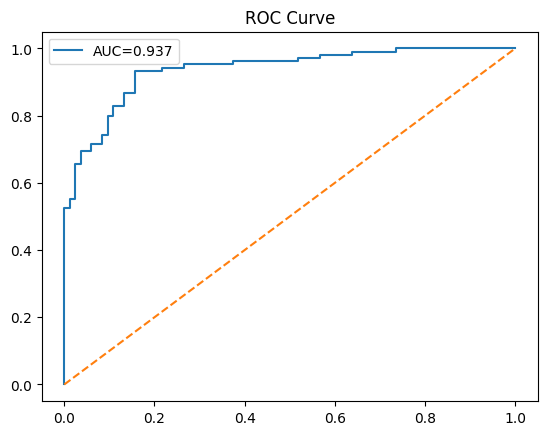


Training with LR=0.001
MLP:
Epoch 1 | Train=0.7923 | Val=0.6603
Epoch 2 | Train=0.6838 | Val=0.6430
Epoch 3 | Train=0.6588 | Val=0.6230
Epoch 4 | Train=0.6336 | Val=0.6400
Epoch 5 | Train=0.6189 | Val=0.5966
Epoch 6 | Train=0.5904 | Val=0.5987
Epoch 7 | Train=0.6158 | Val=0.6057
Epoch 8 | Train=0.6050 | Val=0.6162
Epoch 9 | Train=0.5773 | Val=0.6244
Epoch 10 | Train=0.5700 | Val=0.5921
Epoch 11 | Train=0.5762 | Val=0.5741
Epoch 12 | Train=0.5801 | Val=0.5733
Epoch 13 | Train=0.5670 | Val=0.5749
Epoch 14 | Train=0.5912 | Val=0.6243
Epoch 15 | Train=0.5571 | Val=0.5899
Epoch 16 | Train=0.5706 | Val=0.5277
Epoch 17 | Train=0.5683 | Val=0.5679
Epoch 18 | Train=0.5566 | Val=0.5528
Epoch 19 | Train=0.5479 | Val=0.5578
Epoch 20 | Train=0.5510 | Val=0.5434


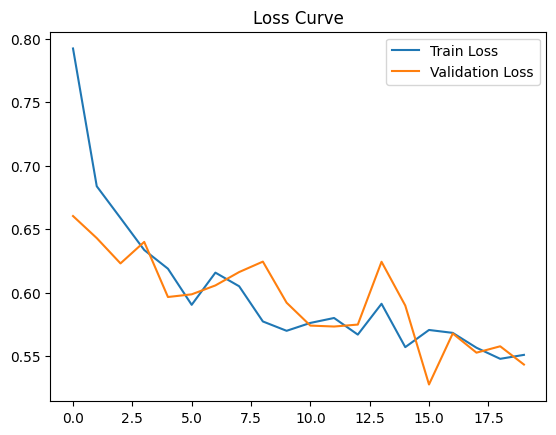

MLP Results:
              precision    recall  f1-score   support

           0       0.66      0.87      0.75        83
           1       0.86      0.65      0.74       105

    accuracy                           0.74       188
   macro avg       0.76      0.76      0.74       188
weighted avg       0.77      0.74      0.74       188



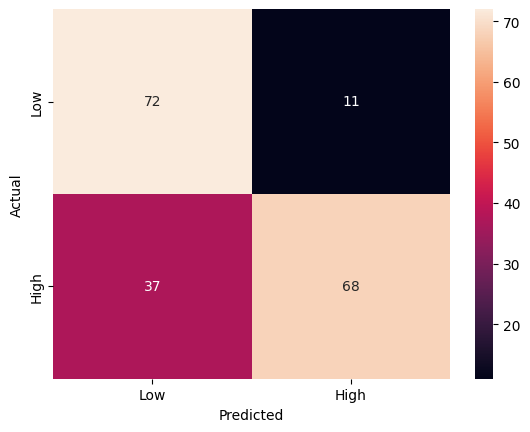

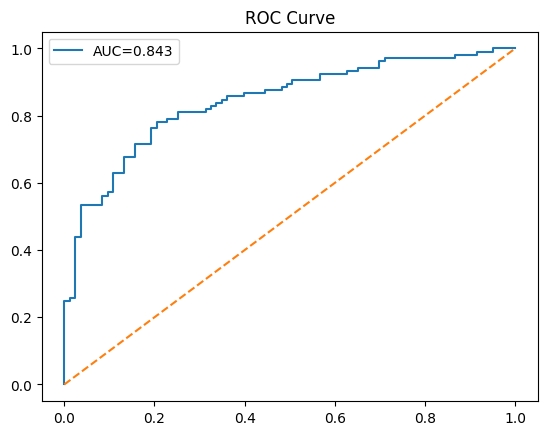

CNN:
Epoch 1 | Train=0.7434 | Val=0.6315
Epoch 2 | Train=0.6344 | Val=0.6185
Epoch 3 | Train=0.6203 | Val=0.5605
Epoch 4 | Train=0.5934 | Val=0.5173
Epoch 5 | Train=0.5487 | Val=0.5438
Epoch 6 | Train=0.5294 | Val=0.6118
Epoch 7 | Train=0.5009 | Val=0.5389
Epoch 8 | Train=0.4735 | Val=0.4730
Epoch 9 | Train=0.4906 | Val=0.4401
Epoch 10 | Train=0.4808 | Val=0.5056
Epoch 11 | Train=0.4619 | Val=0.4556
Epoch 12 | Train=0.4316 | Val=0.4043
Epoch 13 | Train=0.4436 | Val=0.5075
Epoch 14 | Train=0.4596 | Val=0.4615
Epoch 15 | Train=0.4095 | Val=0.4363
Epoch 16 | Train=0.4214 | Val=0.3858
Epoch 17 | Train=0.3847 | Val=0.4273
Epoch 18 | Train=0.3631 | Val=0.3826
Epoch 19 | Train=0.3654 | Val=0.5616
Epoch 20 | Train=0.3701 | Val=0.4801


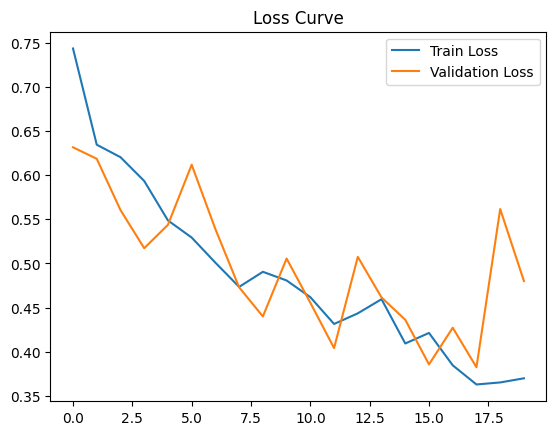

CNN Results:
              precision    recall  f1-score   support

           0       0.88      0.73      0.80        83
           1       0.82      0.92      0.87       105

    accuracy                           0.84       188
   macro avg       0.85      0.83      0.83       188
weighted avg       0.85      0.84      0.84       188



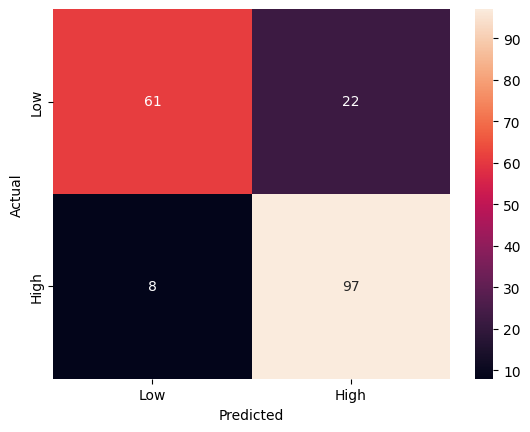

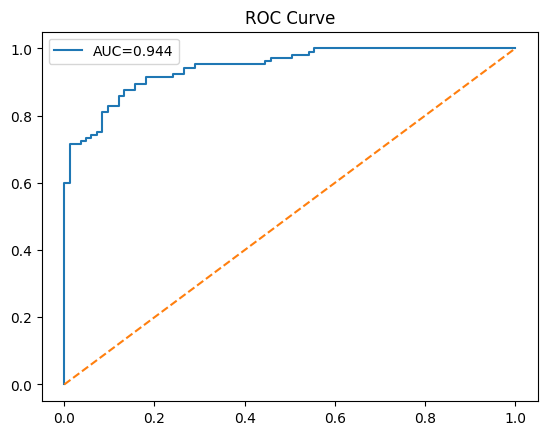


Training with LR=0.005
MLP:
Epoch 1 | Train=1.1766 | Val=0.6938
Epoch 2 | Train=0.7039 | Val=0.6856
Epoch 3 | Train=0.6897 | Val=0.6764
Epoch 4 | Train=0.6761 | Val=0.6728
Epoch 5 | Train=0.6802 | Val=0.6364
Epoch 6 | Train=0.6679 | Val=0.6549
Epoch 7 | Train=0.6621 | Val=0.6165
Epoch 8 | Train=0.6578 | Val=0.6122
Epoch 9 | Train=0.6388 | Val=0.6058
Epoch 10 | Train=0.6422 | Val=0.6067
Epoch 11 | Train=0.6672 | Val=0.6519
Epoch 12 | Train=0.6803 | Val=0.6626
Epoch 13 | Train=0.6804 | Val=0.6377
Epoch 14 | Train=0.6549 | Val=0.6367
Early stopping triggered


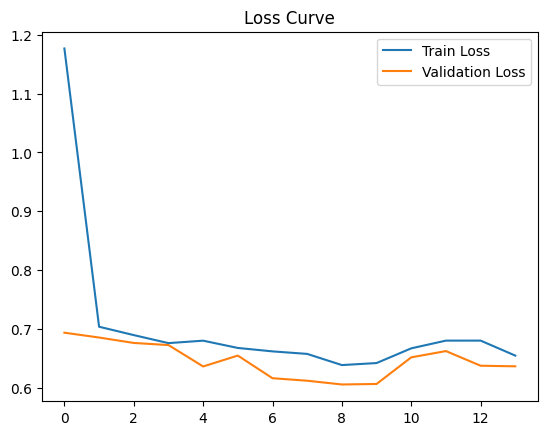

MLP Results:
              precision    recall  f1-score   support

           0       0.75      0.58      0.65        83
           1       0.72      0.85      0.78       105

    accuracy                           0.73       188
   macro avg       0.73      0.71      0.72       188
weighted avg       0.73      0.73      0.72       188



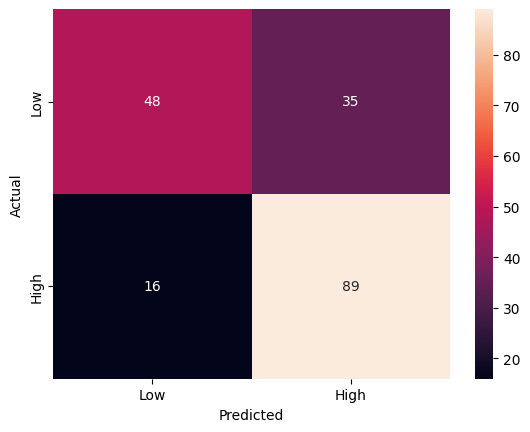

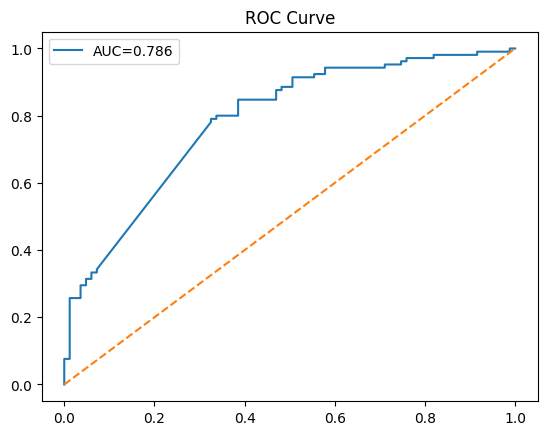

CNN:
Epoch 1 | Train=1.1506 | Val=0.6418
Epoch 2 | Train=0.7090 | Val=0.6773
Epoch 3 | Train=0.6614 | Val=0.6934
Epoch 4 | Train=0.6943 | Val=0.6976
Epoch 5 | Train=0.6998 | Val=0.6597
Epoch 6 | Train=0.6646 | Val=0.5837
Epoch 7 | Train=0.6266 | Val=0.6006
Epoch 8 | Train=0.6222 | Val=0.6156
Epoch 9 | Train=0.6683 | Val=0.5665
Epoch 10 | Train=0.6125 | Val=0.5762
Epoch 11 | Train=0.6300 | Val=0.5906
Epoch 12 | Train=0.6266 | Val=0.5867
Epoch 13 | Train=0.6299 | Val=0.5891
Epoch 14 | Train=0.6315 | Val=0.6024
Early stopping triggered


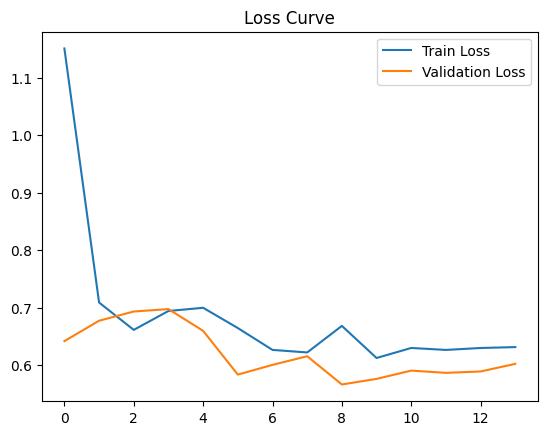

CNN Results:
              precision    recall  f1-score   support

           0       0.89      0.51      0.65        83
           1       0.71      0.95      0.81       105

    accuracy                           0.76       188
   macro avg       0.80      0.73      0.73       188
weighted avg       0.79      0.76      0.74       188



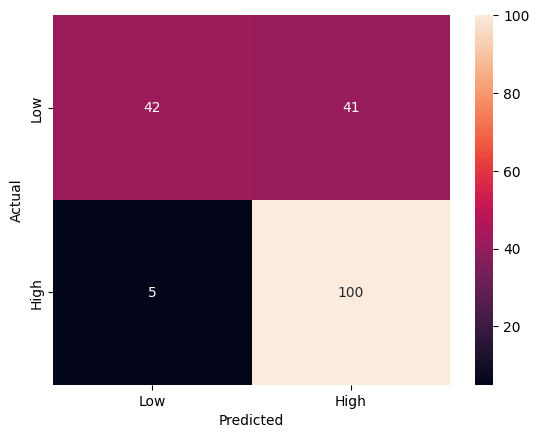

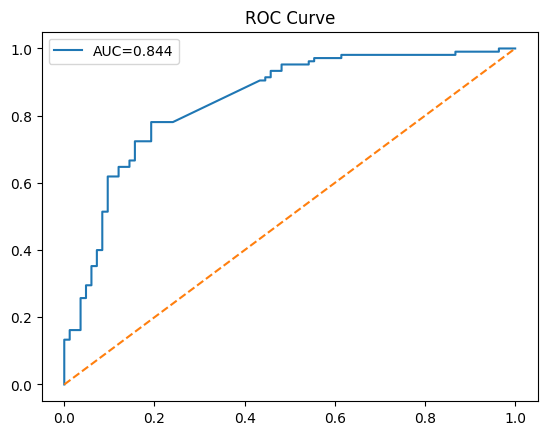

In [ ]:
#running the trainer
trainer = Review1Trainer(path)
results = trainer.run()

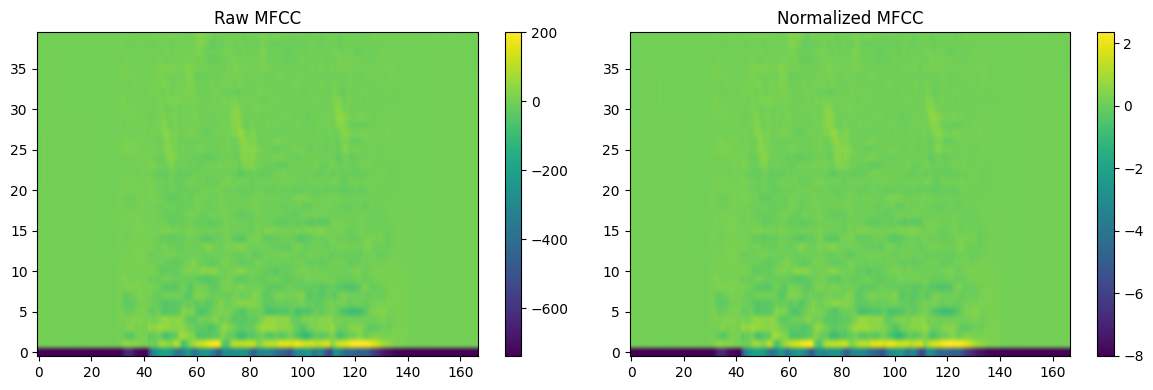

In [ ]:
#visualizing MFCC features of a sample audio file
extractor = AudioFeatureExtractor()

# Pick a random sample
import random
sample_file = random.choice(dataset_vis.file_paths)

# Load signal
signal = extractor.load_audio(sample_file)

# Extract MFCC
mfcc_raw = extractor.extract_mfcc(signal)
mfcc_norm = extractor.normalize(mfcc_raw)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(mfcc_raw, aspect="auto", origin="lower")
plt.title("Raw MFCC")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(mfcc_norm, aspect="auto", origin="lower")
plt.title("Normalized MFCC")
plt.colorbar()

plt.tight_layout()
plt.show()

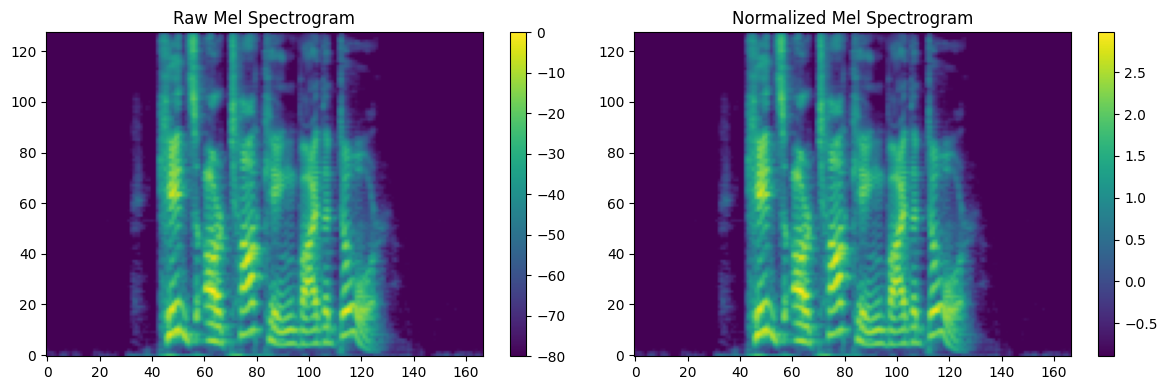

In [ ]:
#visualizing Mel spectrogram features of a sample audio file
mel_raw = extractor.extract_mel(signal)
mel_norm = extractor.normalize(mel_raw)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(mel_raw, aspect="auto", origin="lower")
plt.title("Raw Mel Spectrogram")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(mel_norm, aspect="auto", origin="lower")
plt.title("Normalized Mel Spectrogram")
plt.colorbar()

plt.tight_layout()
plt.show()

In [ ]:
#function to visualize model predictions on a sample audio file
def visualize_prediction(model, file_path, feature_type="mfcc"):

    model.eval()
    extractor = AudioFeatureExtractor()

    signal = extractor.load_audio(file_path)

    if feature_type == "mfcc":
        feature = extractor.extract_mfcc(signal)
    else:
        feature = extractor.extract_mel(signal)

    feature = extractor.pad_or_truncate(feature)
    feature = extractor.normalize(feature)
    feature_tensor = torch.tensor(feature, dtype=torch.float32)

    if feature_type == "mel":
        feature_tensor = feature_tensor.unsqueeze(0)

    feature_tensor = feature_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(feature_tensor)
        probs = torch.softmax(output, dim=1)[0].cpu().numpy()

    predicted_class = np.argmax(probs)
    labels_map = ["Low Stress", "High Stress"]

    # Plot waveform
    plt.figure(figsize=(14,4))

    plt.subplot(1,3,1)
    plt.plot(signal)
    plt.title("Waveform")

    # Plot feature
    plt.subplot(1,3,2)
    plt.imshow(feature, aspect="auto", origin="lower")
    plt.title("Normalized Feature")

    # Plot prediction probabilities
    plt.subplot(1,3,3)
    plt.bar(labels_map, probs)
    plt.title(f"Prediction: {labels_map[predicted_class]}")
    plt.ylabel("Probability")

    plt.tight_layout()
    plt.show()

    print("Predicted:", labels_map[predicted_class])
    print("Confidence:", probs[predicted_class])

LR=0.0001
MLP Prediction:


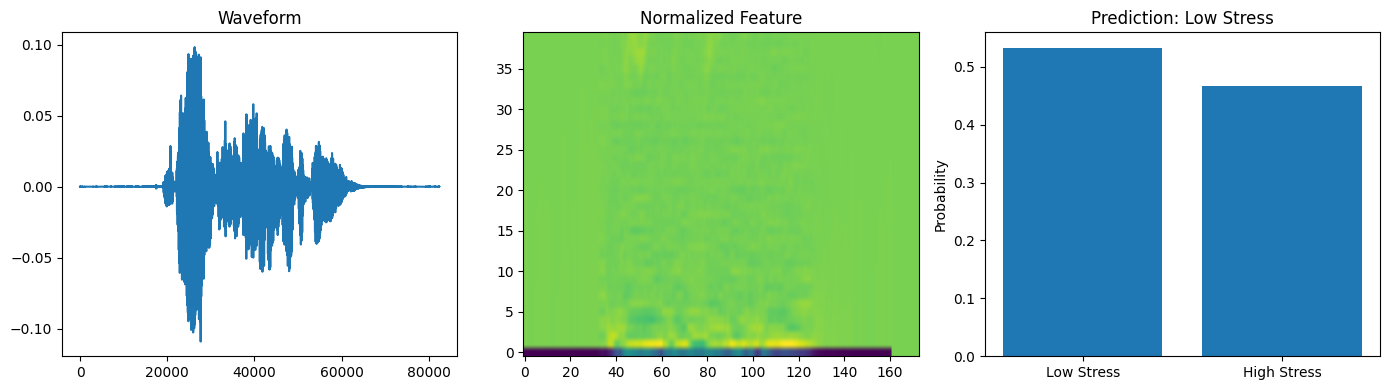

Predicted: Low Stress
Confidence: 0.53274035
CNN Prediction:


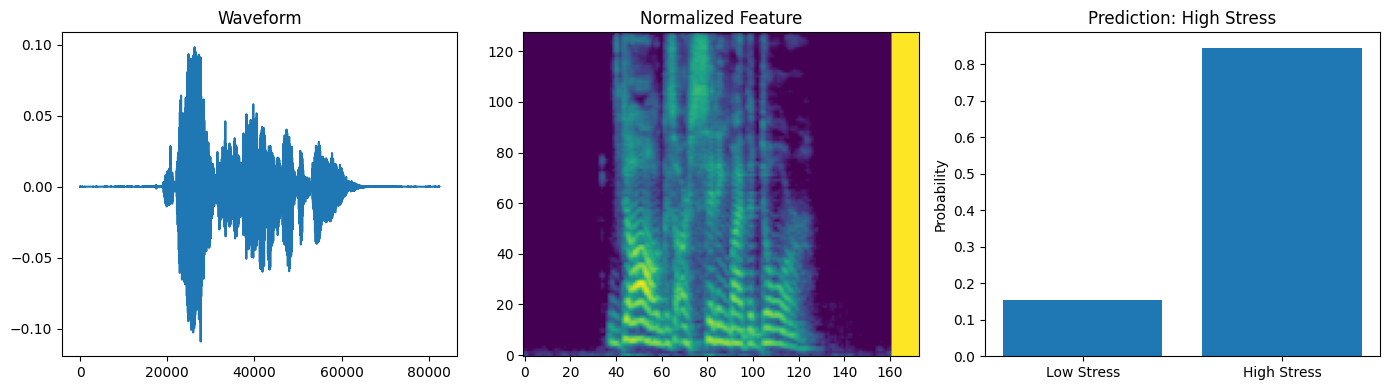

Predicted: High Stress
Confidence: 0.8450114
LR=0.0005
MLP Prediction:


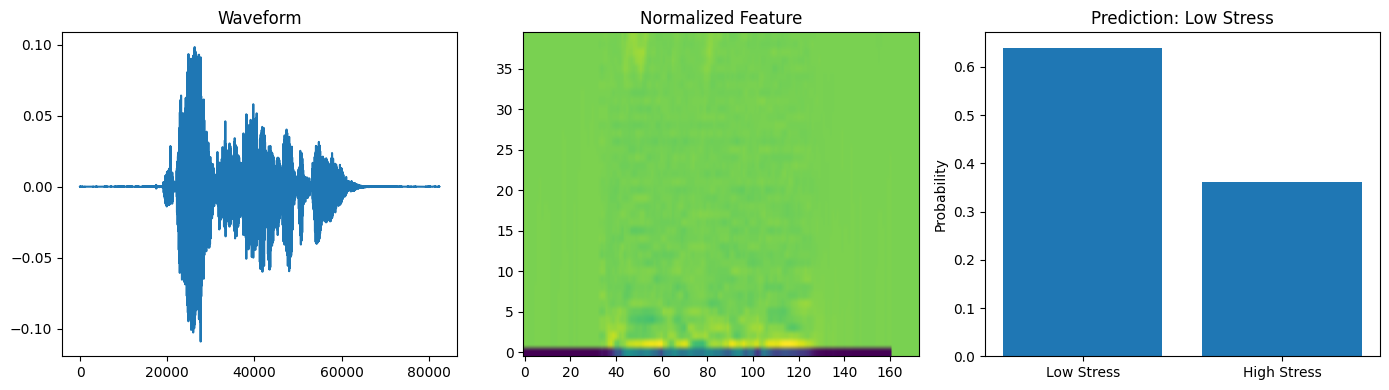

Predicted: Low Stress
Confidence: 0.6396144
CNN Prediction:


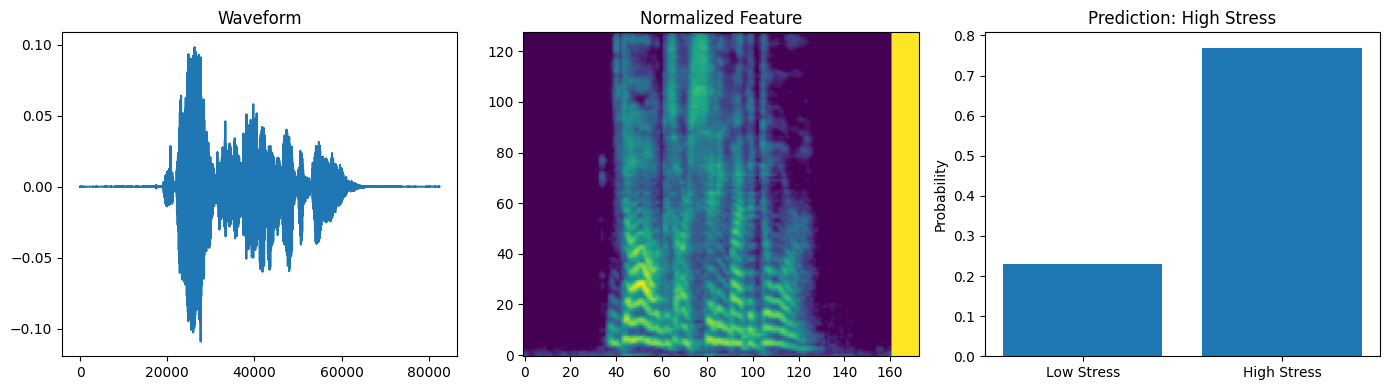

Predicted: High Stress
Confidence: 0.7693517
LR=0.001
MLP Prediction:


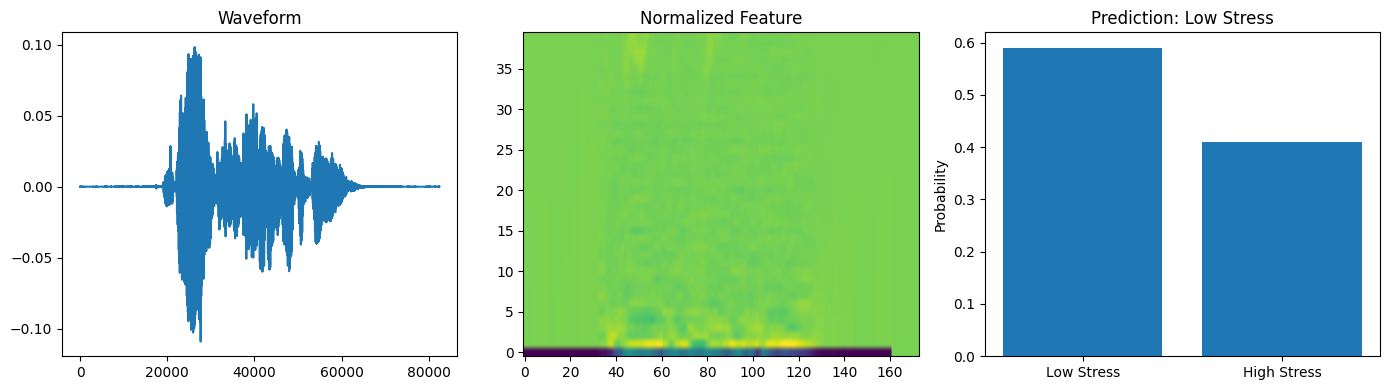

Predicted: Low Stress
Confidence: 0.5901477
CNN Prediction:


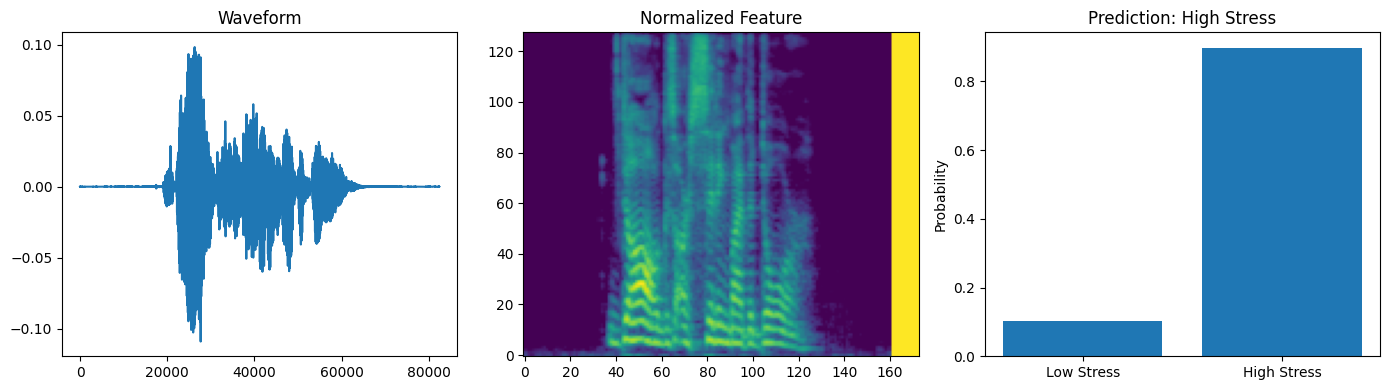

Predicted: High Stress
Confidence: 0.89801264
LR=0.005
MLP Prediction:


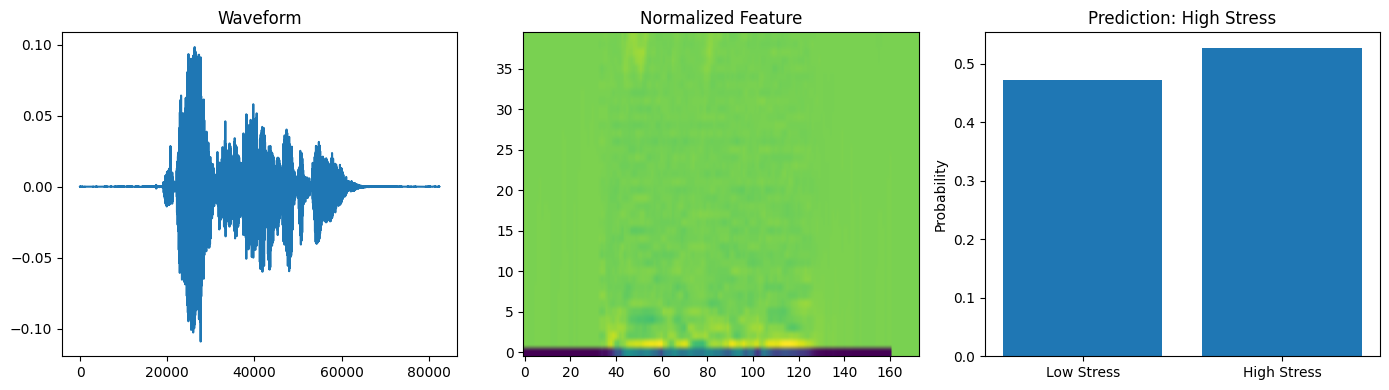

Predicted: High Stress
Confidence: 0.5276318
CNN Prediction:


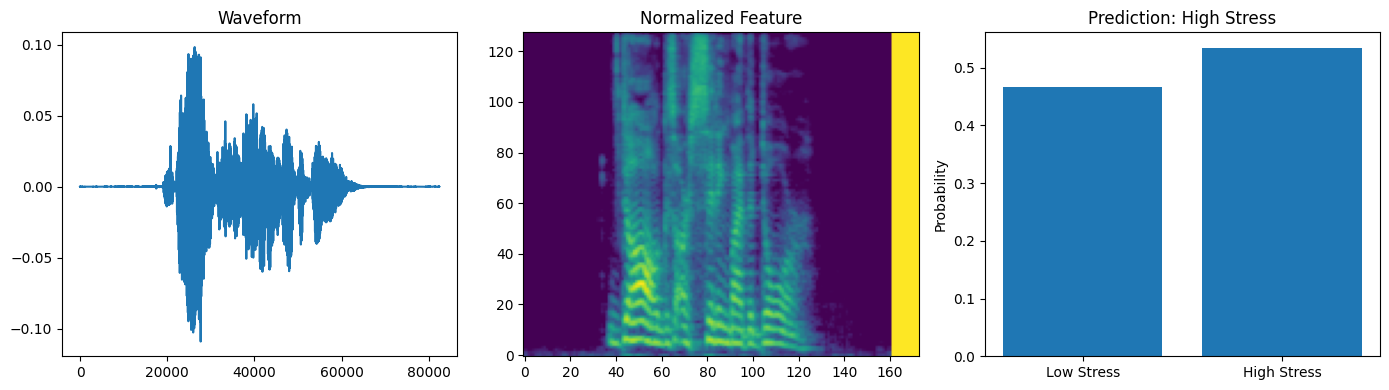

Predicted: High Stress
Confidence: 0.53436583


In [20]:
# Random test sample
test_file = random.choice(dataset_vis.file_paths)

for i, (lr, result) in enumerate(results.items()):
    mlp = result["mlp"]
    cnn = result["cnn"]
    print(f"LR={lr}")
    print("MLP Prediction:")
    visualize_prediction(mlp, test_file, feature_type="mfcc")

    print("CNN Prediction:")
    visualize_prediction(cnn, test_file, feature_type="mel")